# Replica of the scITD Analysis

The goal of this ntoebook is to replicate, on the breast-cancer data which is provided, the analysis which scITD conducts in order to gain insight on how tensor decompositions can be used to meaningfully analyse cell-cycle data.

## 0. Imports:

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns

import tensorly as tl
from tensorly.decomposition import tucker

## 1. Data import:

In [3]:
adata = sc.read_h5ad("../data/breast_cancer_zikry_wayne/T47D_merged.h5ad")

We subset to the following features:

In [14]:
selected_features = [
    'nuclear_mean_HES1', 'nuclear_mean_p53', 'nuclear_mean_pH2AX',
    'nuclear_mean_CDC25c', 'nuclear_mean_CycB1', 'nuclear_mean_p16',
    'nuclear_mean_CDK2','nuclear_mean_cycE1', 'nuclear_mean_pRB',
    'nuclear_mean_PH3','nuclear_mean_cycA2','nuclear_mean_Plk1',
    'DNA_int'
]

adata = adata[:, selected_features]

Understanding our data:

In [15]:
print(f'n_obs x n_vars: {adata.shape}')

n_obs x n_vars: (612372, 13)


In [16]:
print(f'cell barcodes (row index): {adata.obs_names}\n')
print(f'gene/feature names (column index): {adata.var_names}\n')

cell barcodes (row index): Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '144088', '144089', '144090', '144091', '144092', '144093', '144094',
       '144095', '144096', '144097'],
      dtype='object', length=612372)

gene/feature names (column index): Index(['nuclear_mean_HES1', 'nuclear_mean_p53', 'nuclear_mean_pH2AX',
       'nuclear_mean_CDC25c', 'nuclear_mean_CycB1', 'nuclear_mean_p16',
       'nuclear_mean_CDK2', 'nuclear_mean_cycE1', 'nuclear_mean_pRB',
       'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
       'DNA_int'],
      dtype='object')



In [17]:
adata.obs

,core,binucleated,CellID,GMM_phase_labels,DNA_int_obs,nuclear_mean_cycA2_obs,Endocycle,drug_name
0,1.0,1,0,G0,4.514192,162.493695,Polyploid,Control
1,1.0,0,1,S,4.379941,2641.722167,Diploid,Control
2,1.0,0,2,G0,5.348979,159.590886,Polyploid,Control
3,1.0,0,3,G1,2.106505,181.602243,Diploid,Control
4,1.0,0,4,G0,1.826259,155.153846,Diploid,Control
...,...,...,...,...,...,...,...,...
144093,8.0,0,144093,G1,2.205912,240.395580,Diploid,Dinaciclib
144094,8.0,0,144094,G1,2.033355,193.921158,Diploid,Dinaciclib
144095,8.0,0,144095,G0,2.081168,531.183796,Diploid,Dinaciclib
144096,8.0,0,144096,G0,1.971715,174.206118,Diploid,Dinaciclib


In [18]:
total = adata.obs['drug_name'].value_counts().sum()
adata.obs['drug_name'].value_counts() / total

drug_name
Dinaciclib      0.235311
RO-3306         0.224222
Palbociclib     0.151197
Control         0.099938
CVT-313         0.095159
PF-3600         0.081302
Samuraciclib    0.062359
Talazoparib     0.050512
Name: count, dtype: float64

In [19]:
pd.DataFrame(adata.X, columns=adata.var_names, index=adata.obs_names)

,nuclear_mean_HES1,nuclear_mean_p53,nuclear_mean_pH2AX,nuclear_mean_CDC25c,nuclear_mean_CycB1,nuclear_mean_p16,nuclear_mean_CDK2,nuclear_mean_cycE1,nuclear_mean_pRB,nuclear_mean_PH3,nuclear_mean_cycA2,nuclear_mean_Plk1,DNA_int
0,1485.613967,874.170223,2136.317653,234.709505,144.751212,2291.766731,5140.916586,800.507759,396.525703,600.428710,162.493695,188.823472,4.514192
1,1413.356859,1606.262922,1990.681909,235.934394,890.022366,1807.549205,4706.368290,552.378231,1670.795726,1148.586481,2641.722167,461.421471,4.379941
2,1368.803379,654.787506,3116.836918,233.526370,113.201229,1756.368920,1368.954685,631.483871,246.571173,592.180748,159.590886,135.884537,5.348979
3,1446.301122,2701.823986,1445.127696,243.163072,136.157895,1651.933563,2357.413287,698.044003,1072.846419,424.948231,181.602243,125.374461,2.106505
4,1468.494675,1321.991716,2089.118343,226.636686,156.211834,2620.850888,2153.565680,605.657988,297.229586,464.481657,155.153846,180.403550,1.826259
...,...,...,...,...,...,...,...,...,...,...,...,...,...
144093,1671.966851,1571.782320,1242.919337,285.314917,200.794475,2393.575691,2223.079558,660.495028,1109.131492,589.051934,240.395580,182.297238,2.205912
144094,1514.709581,2393.952096,1273.376248,279.006986,140.104790,1202.762475,3536.428144,543.082834,578.515968,1085.689621,193.921158,507.659681,2.033355
144095,1513.505626,1277.599400,1604.366092,251.532633,451.711928,1236.012003,1886.015754,740.874719,384.794449,385.189047,531.183796,223.363091,2.081168
144096,1652.708706,1218.363765,948.016471,255.629647,115.259294,1834.586824,1305.151059,523.526588,173.493176,359.054118,174.206118,161.687529,1.971715


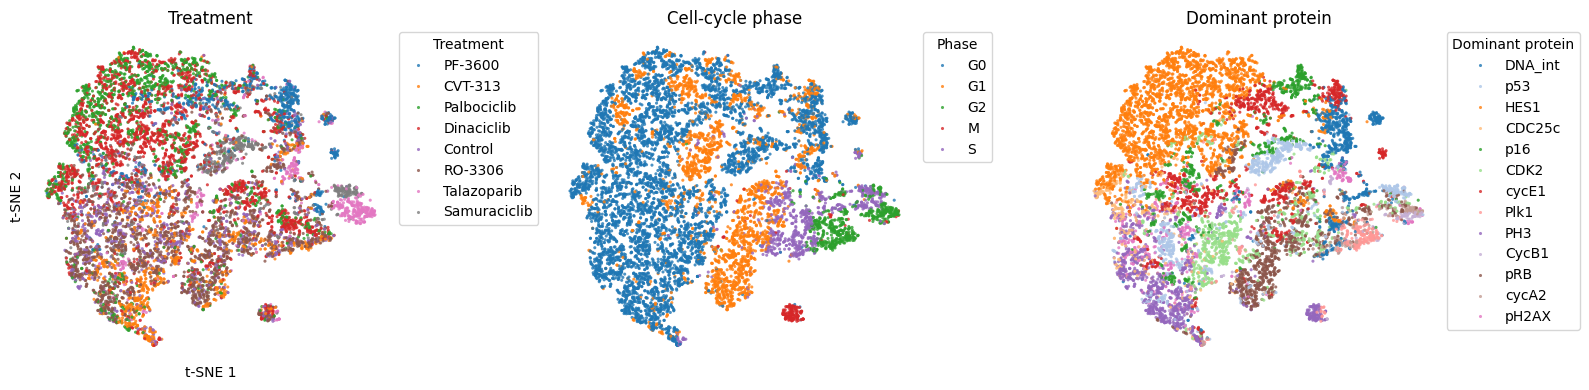

In [40]:
dot_size = 5

# t-SNE on a sampled subset
adata_tsne = sc.pp.subsample(adata, n_obs=min(10000, adata.n_obs), copy=True, random_state=0)

sc.pp.scale(adata_tsne, zero_center=True, max_value=10)
sc.tl.pca(adata_tsne, svd_solver="arpack")
sc.tl.tsne(adata_tsne, use_rep="X_pca", random_state=0)

tsne = pd.DataFrame(
    adata_tsne.obsm["X_tsne"],
    columns=["t-SNE 1", "t-SNE 2"],
    index=adata_tsne.obs_names,
)
tsne["treatment"] = adata_tsne.obs["drug_name"].astype(str).values
tsne["phase"] = adata_tsne.obs["GMM_phase_labels"].astype(str).values
tsne["protein"] = np.asarray(adata_tsne[:, "DNA_int"].X).ravel()


# Set up visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.despine(top=True, right=True, left=True, bottom=True)


# Treatment
sns.scatterplot(
    data=tsne, x="t-SNE 1", y="t-SNE 2", hue="treatment",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[0]
)
axes[0].set_title("Treatment")
axes[0].legend(title="Treatment", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Cell-cycle phase
sns.scatterplot(
    data=tsne, x="t-SNE 1", y="t-SNE 2", hue="phase",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[1]
)
axes[1].set_title("Cell-cycle phase")
axes[1].legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Dominant protein per sample
dominant_protein = adata_tsne[:, selected_features].to_df().idxmax(axis=1)
tsne["dominant_protein"] = dominant_protein.str.removeprefix("nuclear_mean_").values

sns.scatterplot(
    data=tsne, x="t-SNE 1", y="t-SNE 2", hue="dominant_protein",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[2], palette="tab20"
)
axes[2].set_title("Dominant protein")
axes[2].legend(
    title="Dominant protein", bbox_to_anchor=(1.02, 1),
    loc="upper left", borderaxespad=0
)


# Final touches
for ax in axes:
    if ax == axes[0]: 
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
    else: 
        ax.set_xlabel("")
        ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 2. Data analysis:

Our idea is to, for a first go, model our tensor via: $\textit{treatment} \times \textit{cell-cycle phase} \times \textit{protein}$. Let $t \in \mathbb{N}$ be the number of treatments, in our case $t = 8$, $c \in \mathbb{N}$ the number of cell-cycle phases, here $c = 5$, and $p \in \mathbb{N}$ be the number of proteins analyzed, here $p = 13$. After performing a Tucker decomposition on said tensor, we may obtain: 

$$
\begin{split}
X & \approx \mathcal{G} \times_1 T \times_2 C \times_3 P \\
        & = (\mathcal{G} \times_2 C \times_3 P) \times_1 T \\
        & = \mathcal{F} \times_1 T 
\end{split}
$$

where $T \in \mathbb{R}^{t_F \times t}$ are the treatment loadings, $C \in \mathbb{R}^{c_F \times c}$ are the cell-cycle-phase loadings, $P \in \mathbb{R}^{p_F \times p}$ are the protein loadings, and $\mathcal{F} \in \mathbb{R}^{t_F \times c \times p}$ is a tensor encoding the effect of the treatment-factors on the cell-cycle across proteins. (Note that $t_F$, $c_F$, and $p_F$ denote the treatment-facotrs, cell-cycle-phase-factors, and protein-factors respectively.)

### 2.1 Pseudobulking:

Similar to Mitchel et al. (2025), we perform pseudobulking, averaging proteins within each treatment and cell-cycle phase and obtaining our tensor by stacking across proteins. To wit, we obtain $p = 13$ matrices of dimensionality $t \times c$, which for a given protein contain the average value for a specific treatment and cell-cycle phase. These are then stacked across the $p = 13$ proteins to result in our pseudobulked tensor.

In [58]:
def pseudobulk(adata):
    # Convert AnnData to DataFrame 
    adata_df = adata.to_df()
    
    # Group by drug_name and GMM_phase_labels, then get mean of each group
    pseudobulk_df = adata_df.groupby([adata.obs["drug_name"], adata.obs["GMM_phase_labels"]], observed=True).mean()
    
    # z-scale across each protein 
    pseudobulk_df_scales = (pseudobulk_df - pseudobulk_df.mean()) / pseudobulk_df.std()
    
    # Reshape to (n_drugs, n_phases, n_features)
    return_tensor = pseudobulk_df_scales.values.reshape(len(adata.obs["drug_name"].cat.categories), len(adata.obs["GMM_phase_labels"].cat.categories), -1)
    return return_tensor

In [59]:
pseudobulk_tensor = pseudobulk(adata)
print(f'Pseudobulk tensor shape: {pseudobulk_tensor.shape}')

print("Example pseudobulk values for the first protein (HES1):")
pd.DataFrame(pseudobulk_tensor[:, :, 0], index=adata.obs["drug_name"].cat.categories, columns=adata.obs["GMM_phase_labels"].cat.categories)

Pseudobulk tensor shape: (8, 5, 13)
Example pseudobulk values for the first protein (HES1):


,G0,G1,G2,M,S
CVT-313,-1.658127,-1.537296,-1.397427,-1.579064,-1.817843
Control,-0.624428,-0.628101,-0.538686,-0.571707,-0.869792
Dinaciclib,0.810237,0.819398,0.900878,1.114190,0.669795
PF-3600,0.818456,0.943803,1.090782,1.434559,0.984311
Palbociclib,1.012312,1.092198,1.215610,1.523170,1.041881
RO-3306,-0.789765,-0.705453,-0.458635,-0.332323,-0.684381
Samuraciclib,0.108437,0.411378,0.719480,1.116124,0.216768
Talazoparib,-1.044254,-1.030514,-0.466662,-0.388628,-0.920683


### 2.2 Determine rank for Tucker decomposition:

---